<div style="background-color: #1a1a1a; padding: 25px; border-radius: 8px; border-left: 10px solid #e74c3c; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
    <h1 style="color: #ecf0f1; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-size: 38px; font-weight: 600; margin: 0; letter-spacing: 1px;">EGYPTIAN LICENSE PLATE RECOGNITION</h1>
    <p style="color: #bdc3c7; font-family: 'Segoe UI', sans-serif; margin: 10px 0 0 0; font-size: 16px; font-weight: 400;">Advanced Digital Image Processing & Preprocessing Implementation</p>
    <p style="color: #95a5a6; font-family: 'Consolas', monospace; margin: 5px 0 0 0; font-size: 13px;">Phase 1: Fundamental Preprocessing Completion</p>
</div>


## Cell 1: Dataset Path Setup
**Description:** Defines the path to the dataset and searches for all image files in the Vehicles folder. Verifies the path exists and counts the total number of images found (JPG, PNG, BMP, JPEG formats).

In [21]:
import os, glob
from pathlib import Path

# Main local path to the dataset
DATASET_PATH = r"C:\Users\moman\Desktop\Egyptian License Plates\Egyptian License Plates Dataset\EALPR Vechicles dataset\Vehicles"

# Verify path and collect image files
if os.path.exists(DATASET_PATH):
    # Search for common image formats recursively
    image_files = glob.glob(os.path.join(DATASET_PATH, "**/*.*"), recursive=True)
    image_files = [f for f in image_files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    image_files.sort()
    
    # Display results
    print(f"Total number of images found: {len(image_files)}")
    print(f"Dataset path used: {DATASET_PATH}")
else:
    print(f"Error: Dataset path not found: {DATASET_PATH}")


Total number of images found: 2087
Dataset path used: C:\Users\moman\Desktop\Egyptian License Plates\Egyptian License Plates Dataset\EALPR Vechicles dataset\Vehicles


## Cell 2: Library Imports & Configuration
**Description:** Imports all necessary Python libraries (NumPy, Matplotlib, OpenCV) and configures plotting parameters. Sets up the environment for image processing tasks.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os, glob
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

## Cell 3: Load & Display Sample Images
**Description:** Loads and displays 9 random sample images from the dataset using a fixed random seed. Allows reproducible random selection of images and selects one image for further processing.

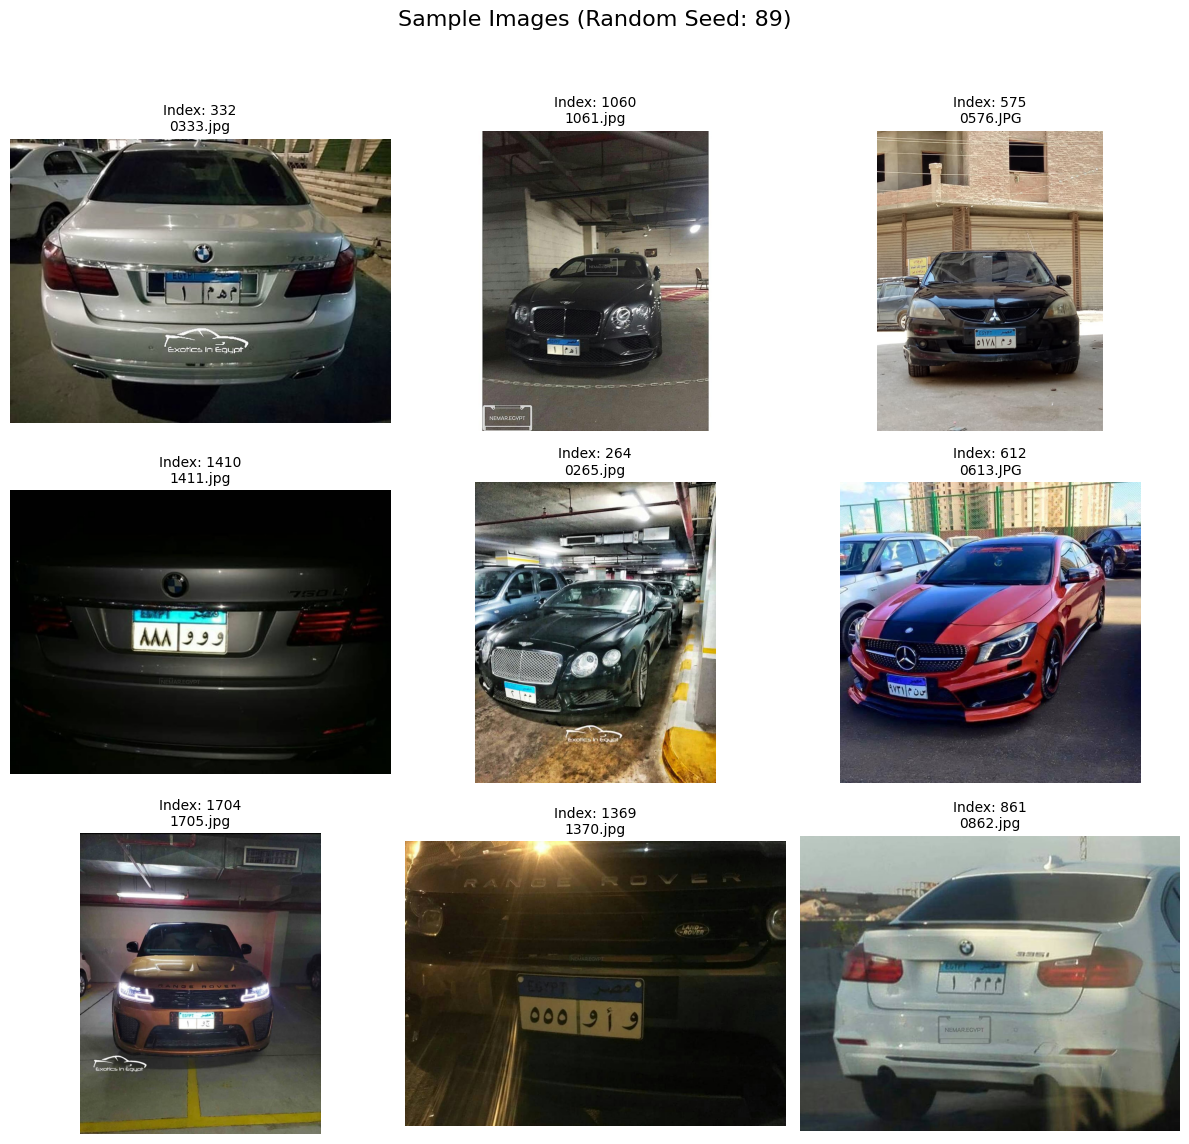

Current selected index: 575
Filename: 0576.JPG


In [23]:
import random

# Change this seed value (e.g., 42, 100, 7) to get a different fixed random set
RANDOM_SEED = 89
random.seed(RANDOM_SEED)

if not image_files:
    print("No images found. Please check Cell 1.")
else:
    num_samples = min(9, len(image_files))
    
    # This will pick the same "random" images every time you run the cell
    sample_indices = random.sample(range(len(image_files)), num_samples)
    
    fig = plt.figure(figsize=(12, 12))
    plt.suptitle(f'Sample Images (Random Seed: {RANDOM_SEED})', fontsize=16)

    for i, idx in enumerate(sample_indices):
        img_path = image_files[idx]
        img = cv2.imread(img_path)
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.subplot(3, 3, i + 1)
            plt.imshow(img_rgb)
            plt.title(f"Index: {idx}\n{Path(img_path).name}", fontsize=10)
            plt.axis('off')
            
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Selecting the first image from this set for processing
    selected_idx = sample_indices[2]
    sample_img = cv2.imread(image_files[selected_idx])
    sample_gray = cv2.cvtColor(sample_img, cv2.COLOR_BGR2GRAY)
    
    print(f"Current selected index: {selected_idx}")
    print(f"Filename: {Path(image_files[selected_idx]).name}")


## Cell 4: Histogram Equalization
**Description:** Applies OpenCV's histogram equalization to enhance image contrast. Compares the original and equalized images along with their histograms to show the difference in pixel distribution.

### Section 1 — Spatial Domain Enhancement

C:\Users\moman\AppData\Local\Temp\ipykernel_28116\1814602344.py:18: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1, 0].hist(sample_gray.flatten(), 256, [0, 256], color='r')
C:\Users\moman\AppData\Local\Temp\ipykernel_28116\1814602344.py:24: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1, 1].hist(equalized_gray.flatten(), 256, [0, 256], color='b')


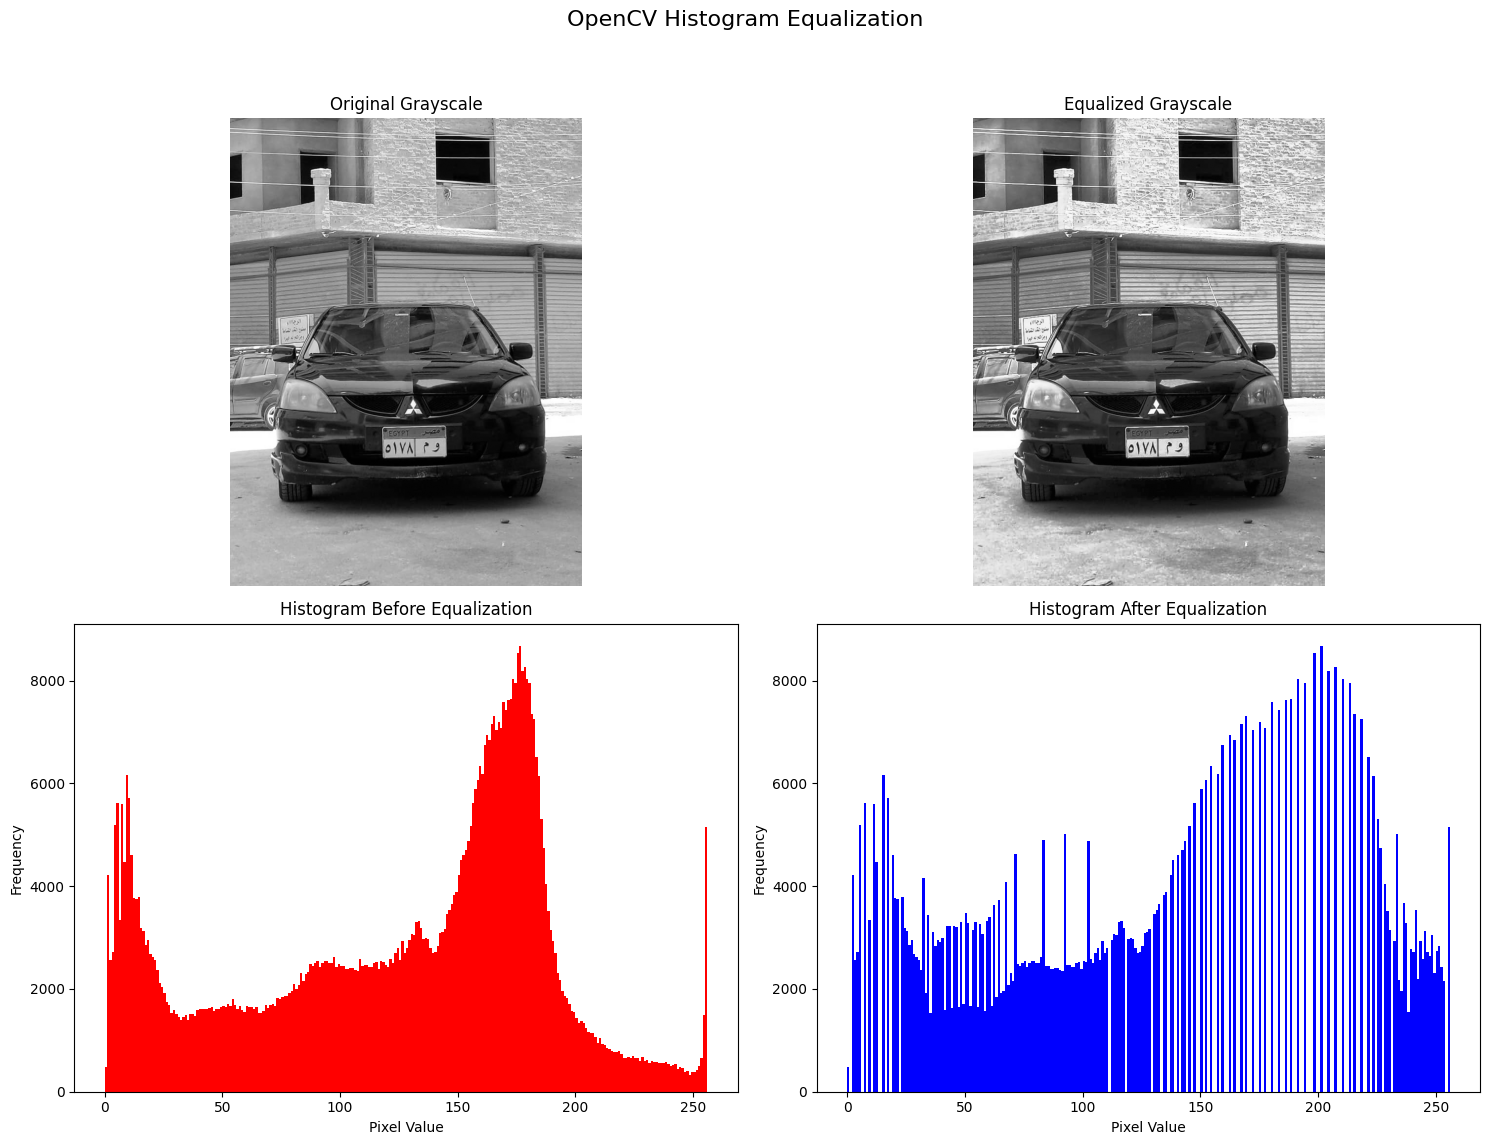

In [24]:
# Apply OpenCV's built-in histogram equalization to sample_gray
equalized_gray = cv2.equalizeHist(sample_gray)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('OpenCV Histogram Equalization', fontsize=16)

# Original Image
axes[0, 0].imshow(sample_gray, cmap='gray')
axes[0, 0].set_title('Original Grayscale')
axes[0, 0].axis('off')

# Equalized Image
axes[0, 1].imshow(equalized_gray, cmap='gray')
axes[0, 1].set_title('Equalized Grayscale')
axes[0, 1].axis('off')

# Histogram Before
axes[1, 0].hist(sample_gray.flatten(), 256, [0, 256], color='r')
axes[1, 0].set_title('Histogram Before Equalization')
axes[1, 0].set_xlabel('Pixel Value')
axes[1, 0].set_ylabel('Frequency')

# Histogram After
axes[1, 1].hist(equalized_gray.flatten(), 256, [0, 256], color='b')
axes[1, 1].set_title('Histogram After Equalization')
axes[1, 1].set_xlabel('Pixel Value')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Cell 5: Contrast Stretching (Linear Min-Max)
**Description:** Performs linear contrast stretching by normalizing pixel values to the full range [0, 255]. Stretches the minimum and maximum pixel intensities to enhance overall image contrast.

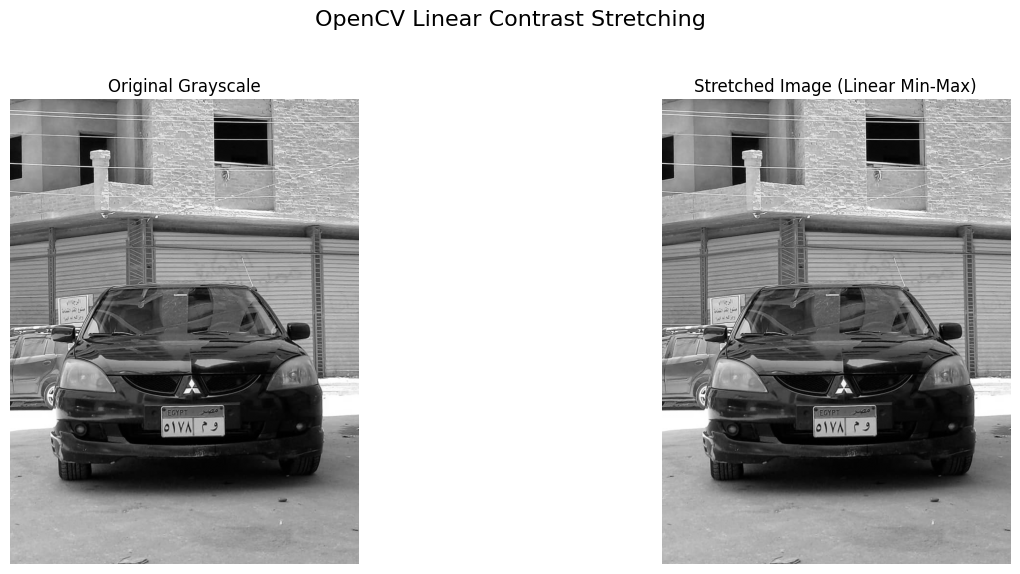

In [25]:
# Apply linear min-max contrast stretching using cv2.normalize
# This stretches the current min and max pixel values to 0 and 255 respectively.
stretched_img = cv2.normalize(sample_gray, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('OpenCV Linear Contrast Stretching', fontsize=16)

axes[0].imshow(sample_gray, cmap='gray')
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

axes[1].imshow(stretched_img, cmap='gray')
axes[1].set_title('Stretched Image (Linear Min-Max)')
axes[1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Cell 6: Mean Filter Denoising
**Description:** Demonstrates denoising using a mean (average) filter. Adds Gaussian noise to the image, then applies a 5x5 mean filter to smooth and reduce the noise.

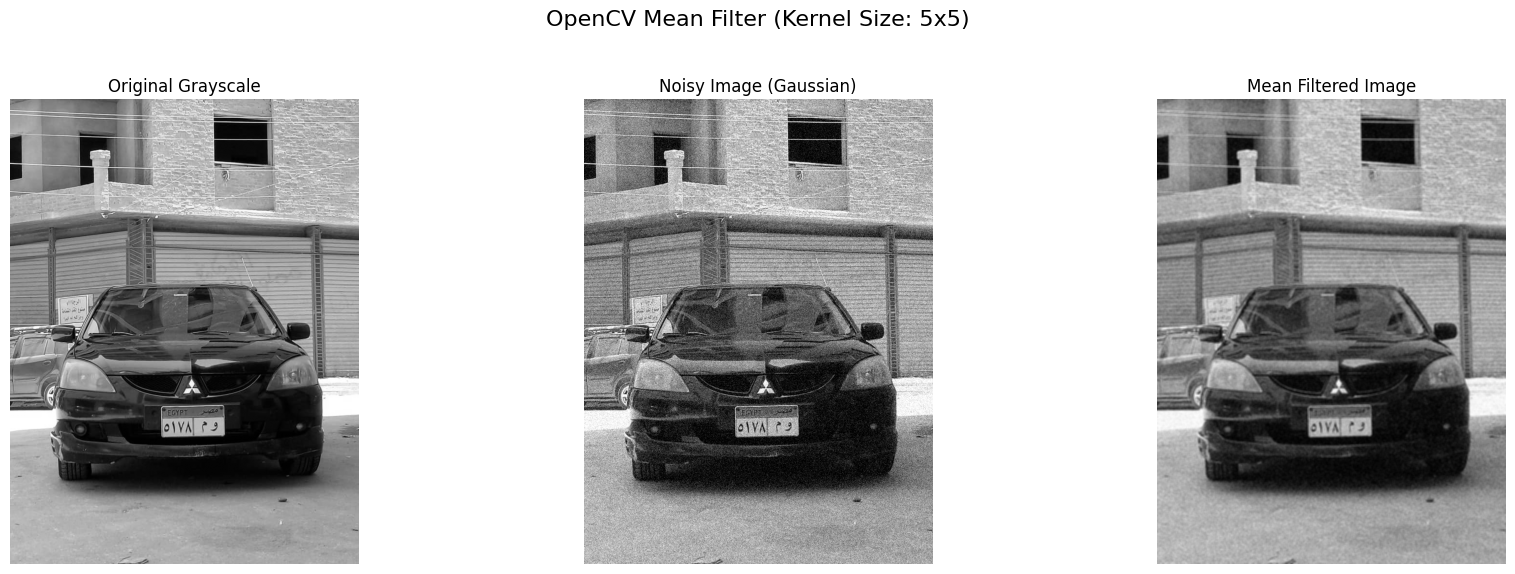

In [26]:
# Add Gaussian noise
noisy_image_mean = sample_gray + np.random.normal(0, 25, sample_gray.shape)
noisy_image_mean = np.clip(noisy_image_mean, 0, 255).astype(np.uint8)

# Apply OpenCV's mean filter
kernel_size_mean = 5
mean_filtered_img = cv2.blur(noisy_image_mean, (kernel_size_mean, kernel_size_mean))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'OpenCV Mean Filter (Kernel Size: {kernel_size_mean}x{kernel_size_mean})', fontsize=16)

axes[0].imshow(sample_gray, cmap='gray')
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

axes[1].imshow(noisy_image_mean, cmap='gray')
axes[1].set_title('Noisy Image (Gaussian)')
axes[1].axis('off')

axes[2].imshow(mean_filtered_img, cmap='gray')
axes[2].set_title('Mean Filtered Image')
axes[2].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Cell 7: Median Filter for Salt & Pepper Noise
**Description:** Applies a median filter to remove salt & pepper noise. This filter is particularly effective for impulse noise and preserves edges better than mean filtering.

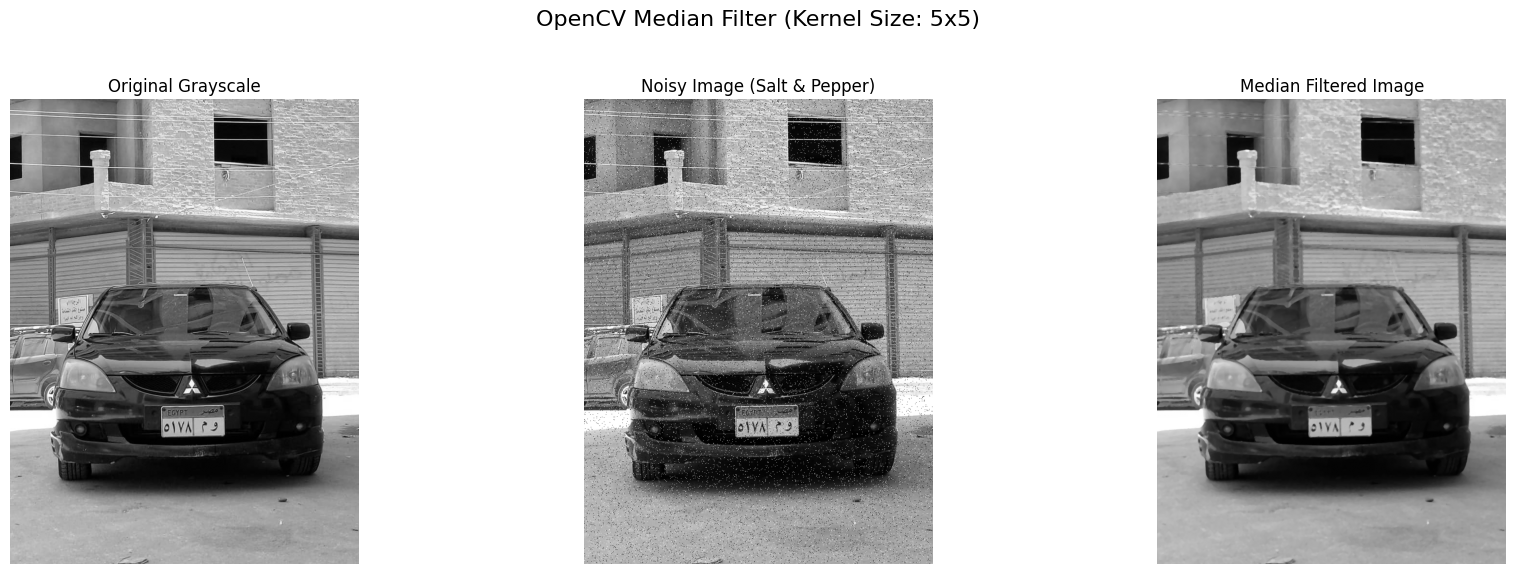

In [27]:
# Add Salt & Pepper noise
noisy_image_median = np.copy(sample_gray)
pepper_amount = 0.05 # 5% of pixels
num_pixels = sample_gray.size

# Salt noise (white pixels)
num_salt = np.ceil(pepper_amount * num_pixels / 2)
coords_salt = [np.random.randint(0, i - 1, int(num_salt)) for i in sample_gray.shape]
noisy_image_median[coords_salt[0], coords_salt[1]] = 255

# Pepper noise (black pixels)
num_pepper = np.ceil(pepper_amount * num_pixels / 2)
coords_pepper = [np.random.randint(0, i - 1, int(num_pepper)) for i in sample_gray.shape]
noisy_image_median[coords_pepper[0], coords_pepper[1]] = 0

# Apply OpenCV's median filter
kernel_size_median = 5
median_filtered_img = cv2.medianBlur(noisy_image_median, kernel_size_median)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'OpenCV Median Filter (Kernel Size: {kernel_size_median}x{kernel_size_median})', fontsize=16)

axes[0].imshow(sample_gray, cmap='gray')
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

axes[1].imshow(noisy_image_median, cmap='gray')
axes[1].set_title('Noisy Image (Salt & Pepper)')
axes[1].axis('off')

axes[2].imshow(median_filtered_img, cmap='gray')
axes[2].set_title('Median Filtered Image')
axes[2].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Cell 8: Laplacian Sharpening
**Description:** Applies sharpening using the Laplacian operator to enhance edges and details. Subtracts the Laplacian from the original image with a tunable sharpening strength parameter.

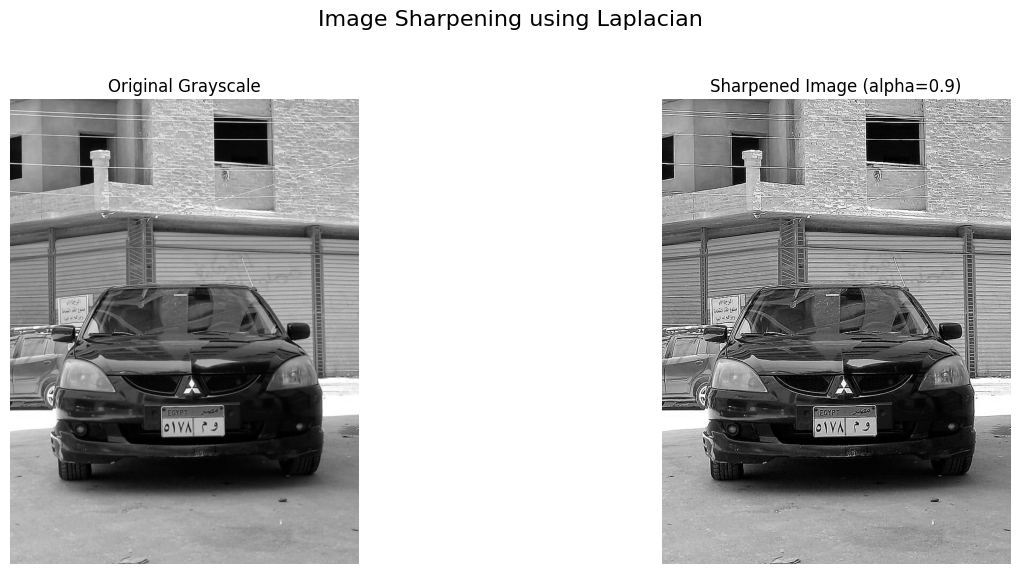

In [28]:
# Convert to float for Laplacian calculation to avoid clipping issues
gray_float = sample_gray.astype(np.float32)

# Compute Laplacian
laplacian = cv2.Laplacian(gray_float, cv2.CV_32F) # Changed output depth to CV_32F to match input

# Apply sharpening formula: sharpened = gray + alpha * Laplacian
# np.clip is used to ensure pixel values stay within [0, 255]
alpha = 0.9 # Sharpening strength
sharpened_img = np.clip(gray_float - alpha * laplacian, 0, 255).astype(np.uint8) # Note: subtract Laplacian for sharpening with positive alpha here

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Image Sharpening using Laplacian', fontsize=16)

axes[0].imshow(sample_gray, cmap='gray')
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

axes[1].imshow(sharpened_img, cmap='gray')
axes[1].set_title(f'Sharpened Image (alpha={alpha})')
axes[1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Cell 9: 2D Fourier Transform & Magnitude Spectrum
**Description:** Computes the 2D Discrete Fourier Transform (FFT) and visualizes the magnitude spectrum. Shows frequency domain representation of the image after shifting zero-frequency components to the center.

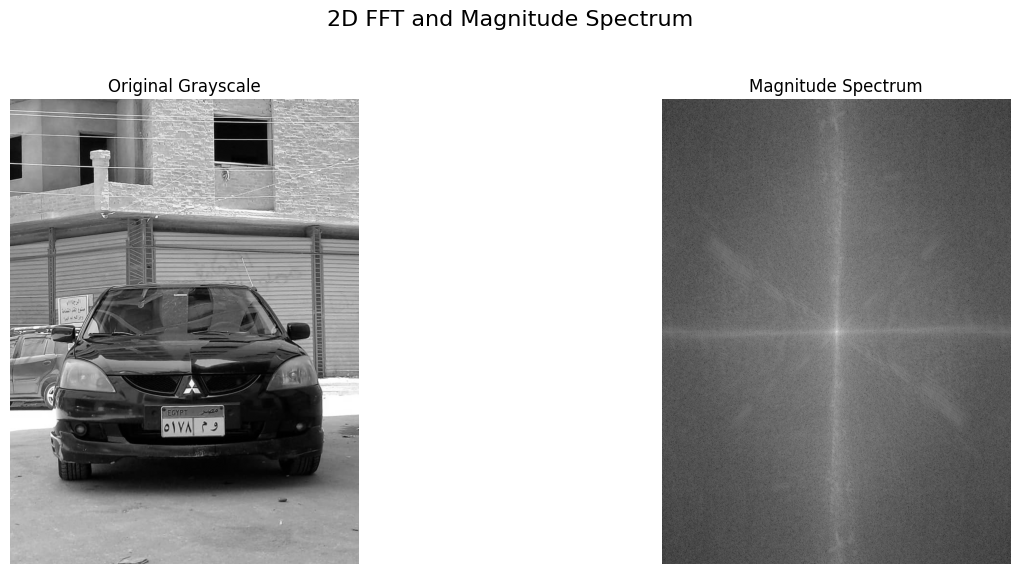

In [29]:
# Perform 2D Discrete Fourier Transform
f = np.fft.fft2(sample_gray)

# Shift the zero-frequency component to the center of the spectrum
fshift = np.fft.fftshift(f)

# Calculate the magnitude spectrum (logarithmic scale for better visualization)
magnitude_spectrum = 20 * np.log(1 + np.abs(fshift))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('2D FFT and Magnitude Spectrum', fontsize=16)

axes[0].imshow(sample_gray, cmap='gray')
axes[0].set_title('Original Grayscale')
axes[0].axis('off')

axes[1].imshow(magnitude_spectrum, cmap='gray')
axes[1].set_title('Magnitude Spectrum')
axes[1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Cell 10: Otsu's Thresholding for Binarization
**Description:** Converts the grayscale image to binary (black and white only) using Otsu's automatic thresholding method. The threshold value is determined automatically to maximize separation between foreground and background.

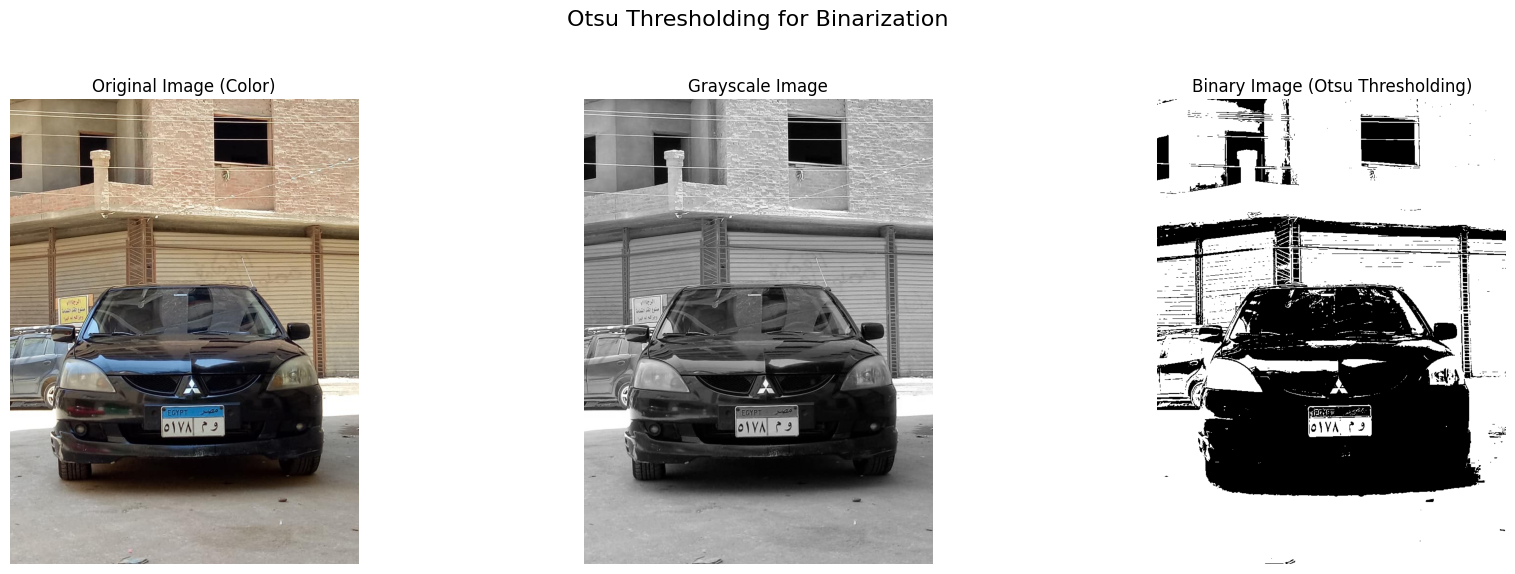

In [32]:
# Convert original BGR image to grayscale (sample_gray is already available)
# Then apply Otsu's thresholding
_, binary_otsu = cv2.threshold(sample_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Otsu Thresholding for Binarization', fontsize=16)

axes[0].imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)) # Original Color for context
axes[0].set_title('Original Image (Color)')
axes[0].axis('off')

axes[1].imshow(sample_gray, cmap='gray')
axes[1].set_title('Grayscale Image')
axes[1].axis('off')

axes[2].imshow(binary_otsu, cmap='gray')
axes[2].set_title('Binary Image (Otsu Thresholding)')
axes[2].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Cell 11: Edge Detection (Sobel & Canny)
**Description:** Compares two edge detection methods: Sobel operator (computes gradient magnitude) and Canny edge detection (multi-stage algorithm). Shows X-gradient, Y-gradient, and combined edges.

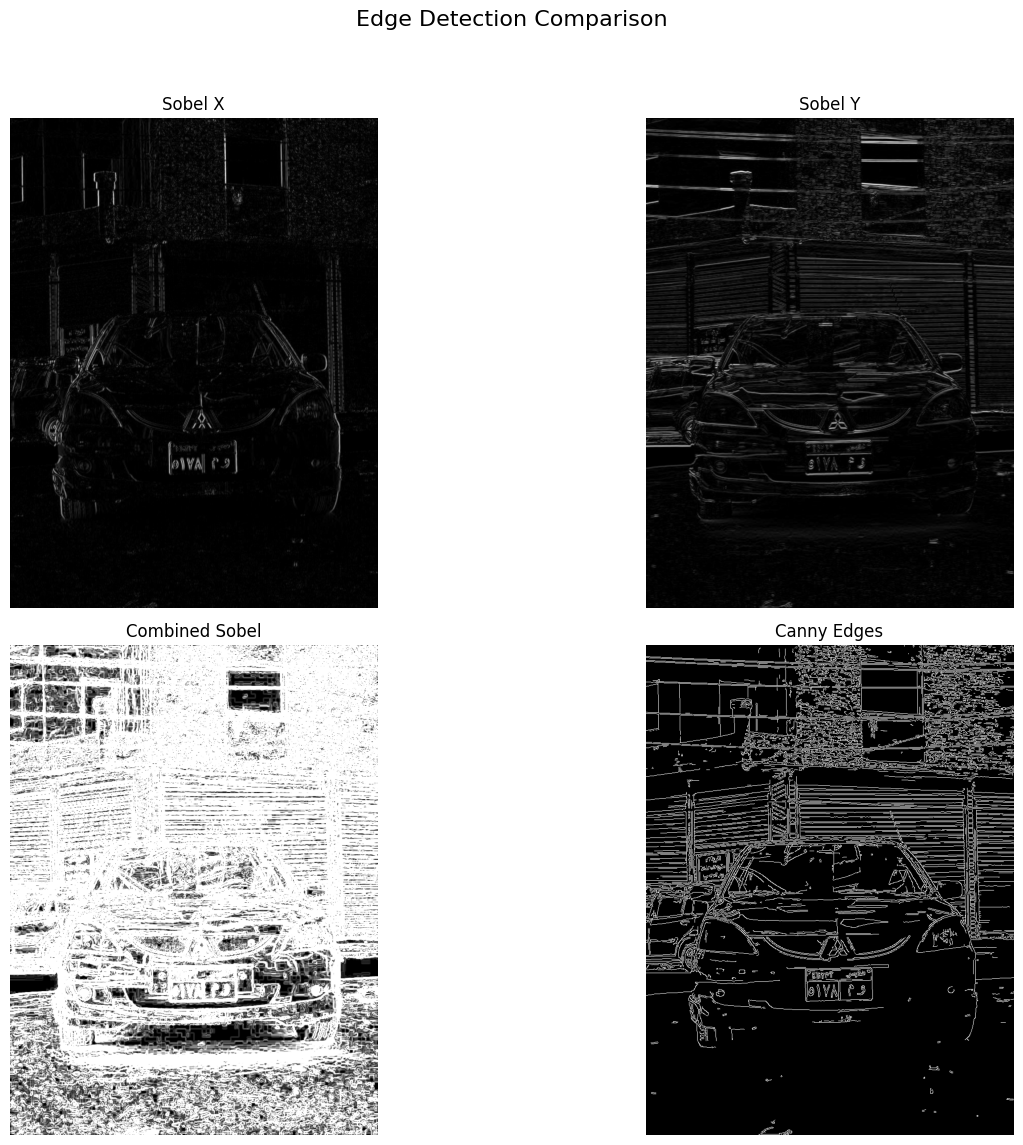

In [33]:
# Compute gradients using Sobel operators
sobelx = cv2.Sobel(sample_gray, cv2.CV_64F, 1, 0, ksize=5) # X-gradient
sobely = cv2.Sobel(sample_gray, cv2.CV_64F, 0, 1, ksize=5) # Y-gradient

# Combine Sobel gradients (magnitude of the gradient)
sobel_combined = np.sqrt(sobelx**2 + sobely**2)
sobel_combined = np.clip(sobel_combined, 0, 255).astype(np.uint8)

# Canny Edge Detection
# Parameters: image, threshold1, threshold2 (minVal, maxVal)
canny_edges = cv2.Canny(sample_gray, 100, 200)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Edge Detection Comparison', fontsize=16)

axes[0, 0].imshow(np.abs(sobelx), cmap='gray')
axes[0, 0].set_title('Sobel X')
axes[0, 0].axis('off')

axes[0, 1].imshow(np.abs(sobely), cmap='gray')
axes[0, 1].set_title('Sobel Y')
axes[0, 1].axis('off')

axes[1, 0].imshow(sobel_combined, cmap='gray')
axes[1, 0].set_title('Combined Sobel')
axes[1, 0].axis('off')

axes[1, 1].imshow(canny_edges, cmap='gray')
axes[1, 1].set_title('Canny Edges')
axes[1, 1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Cell 12: Interactive License Plate Region Selection
**Description:** Provides interactive sliders to manually select and crop the license plate region from the image. Uses IPython widgets to visualize the selected region in real-time and store it for further processing.

In [ ]:
from ipywidgets import interact, IntSlider

def interactive_crop(x_start, x_end, y_start, y_end):
    # Creating the visualization
    temp_img = cv2.cvtColor(sample_gray, cv2.COLOR_GRAY2RGB)
    cv2.rectangle(temp_img, (x_start, y_start), (x_end, y_end), (255, 0, 0), 3)
    
    # Global variables to use the values later in the next cells
    global plate_roi
    plate_roi = sample_gray[y_start:y_end, x_start:x_end]
    
    plt.figure(figsize=(15, 10))
    plt.subplot(1, 2, 1); plt.imshow(temp_img); plt.title('1. Move sliders to select the plate')
    plt.subplot(1, 2, 2); plt.imshow(plate_roi, cmap='gray'); plt.title('2. Resulting Plate Crop')
    plt.show()

# Setting up interactive sliders based on image size
h, w = sample_gray.shape
interact(interactive_crop, 
         x_start=IntSlider(min=0, max=w, step=1, value=int(w*0.3)),
         x_end=IntSlider(min=0, max=w, step=1, value=int(w*0.7)),
         y_start=IntSlider(min=0, max=h, step=1, value=int(h*0.7)),
         y_end=IntSlider(min=0, max=h, step=1, value=int(h*0.95)))


interactive(children=(IntSlider(value=216, description='x_start', max=720), IntSlider(value=503, description='…

<function __main__.interactive_crop(x_start, x_end, y_start, y_end)>

## Cell 13: Master Enhancement Pipeline for License Plate
**Description:** Applies a complete enhancement pipeline to the selected license plate region: sharpening → CLAHE contrast enhancement → Otsu thresholding → morphological cleaning. Produces a clean binary image ready for character recognition.

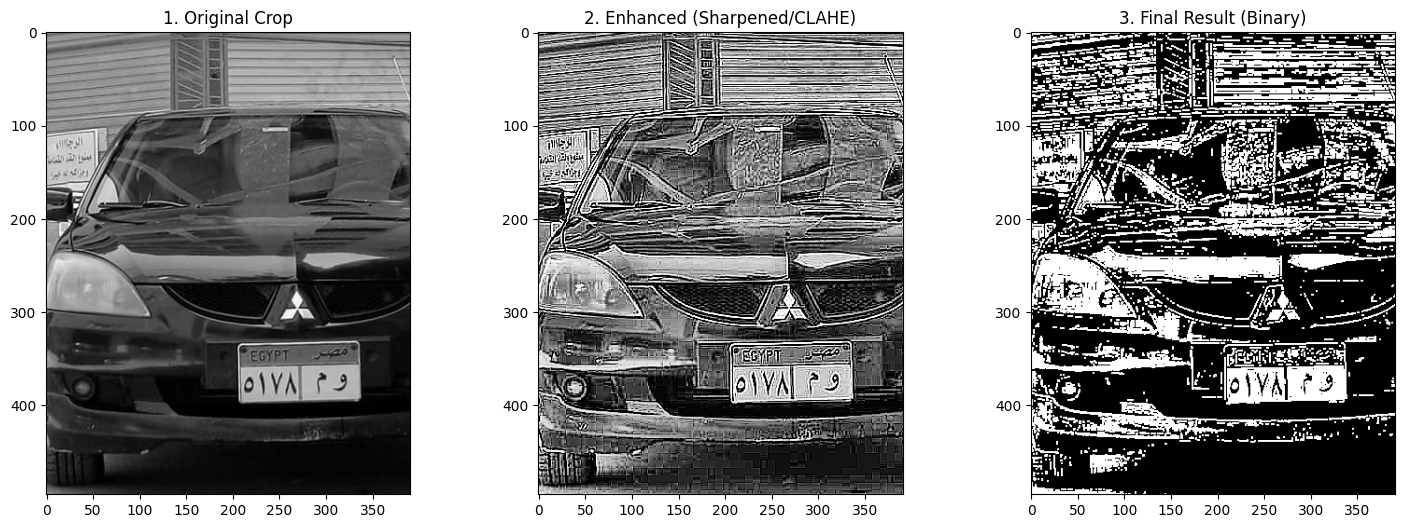

In [52]:
# Master Enhancement for the Selected Plate ROI
def process_selected_plate(roi):
    if roi is None or roi.size == 0:
        print("Error: No ROI selected. Please adjust sliders in the previous cell.")
        return

    # A. Sharpening to fix blur
    kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
    sharpened = cv2.filter2D(roi, -1, kernel)
    
    # B. CLAHE to bring out the numbers
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8))
    enhanced_plate = clahe.apply(sharpened)
    
    # C. Binarization (Otsu's Method) for crystal clear letters
    _, binary_plate = cv2.threshold(enhanced_plate, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # D. Morphological cleaning (to remove small noise)
    kernel_clean = np.ones((2,2), np.uint8)
    final_clean = cv2.morphologyEx(binary_plate, cv2.MORPH_OPEN, kernel_clean)

    # Displaying the difference
    plt.figure(figsize=(18, 6))
    plt.subplot(1, 3, 1); plt.imshow(roi, cmap='gray'); plt.title('1. Original Crop')
    plt.subplot(1, 3, 2); plt.imshow(enhanced_plate, cmap='gray'); plt.title('2. Enhanced (Sharpened/CLAHE)')
    plt.subplot(1, 3, 3); plt.imshow(final_clean, cmap='gray'); plt.title('3. Final Result (Binary)')
    plt.show()

# Execute on your custom crop
process_selected_plate(plate_roi)


## Cell 14: Minimum and Maximum Filters
**Description:** Implements Minimum and Maximum filters using statistical rank filtering. 
- **Minimum Filter:** Replaces each pixel with the minimum value in its neighborhood (similar to erosion), effective for salt noise removal.
- **Maximum Filter:** Replaces each pixel with the maximum value in its neighborhood (similar to dilation), effective for pepper noise removal.


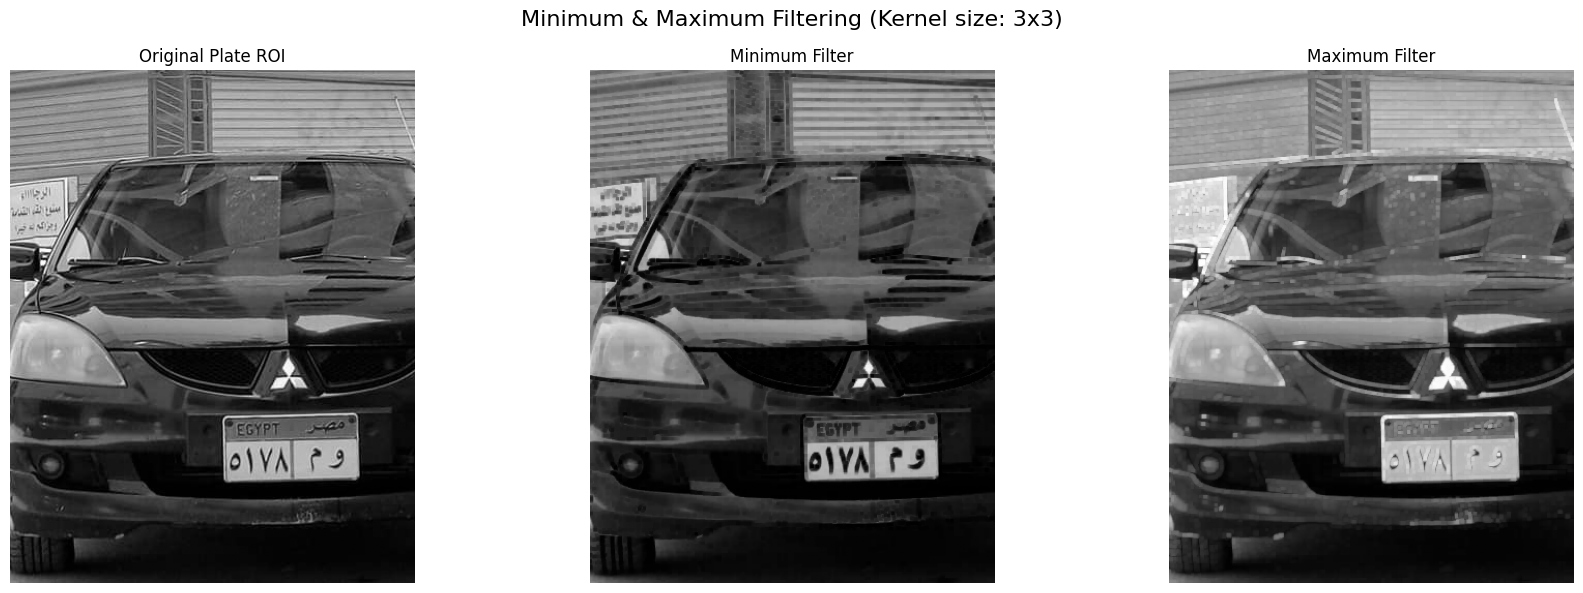

In [53]:
from scipy import ndimage
import matplotlib.pyplot as plt

size = 3

min_filtered = ndimage.minimum_filter(plate_roi, size=size)
max_filtered = ndimage.maximum_filter(plate_roi, size=size)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'Minimum & Maximum Filtering (Kernel size: {size}x{size})', fontsize=16)

axes[0].imshow(plate_roi, cmap='gray')
axes[0].set_title('Original Plate ROI')
axes[0].axis('off')

axes[1].imshow(min_filtered, cmap='gray')
axes[1].set_title('Minimum Filter')
axes[1].axis('off')

axes[2].imshow(max_filtered, cmap='gray')
axes[2].set_title('Maximum Filter')
axes[2].axis('off')

plt.tight_layout()
plt.show()


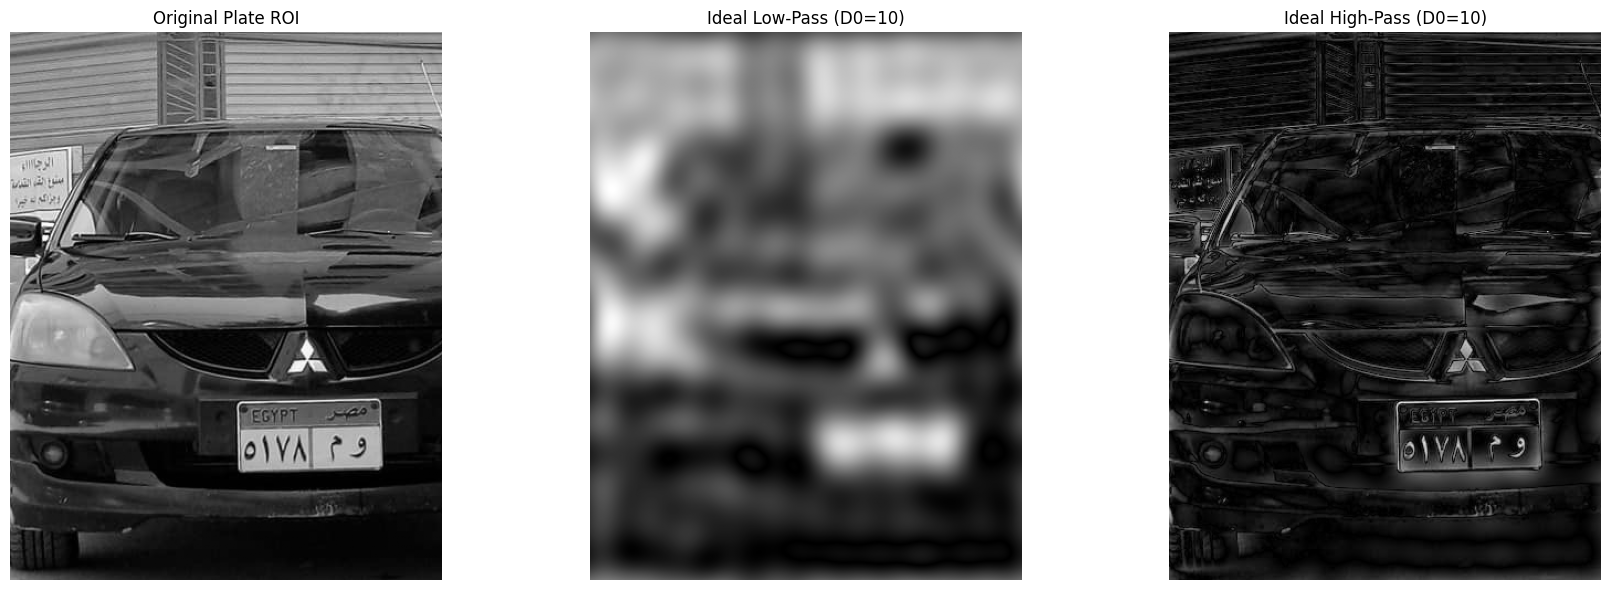

In [54]:
import numpy as np

dft = cv2.dft(np.float32(plate_roi), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

rows, cols = plate_roi.shape
crow, ccol = rows // 2, cols // 2
D0 = 10

mask_low = np.zeros((rows, cols, 2), np.uint8)
mask_high = np.ones((rows, cols, 2), np.uint8)

y, x = np.ogrid[:rows, :cols]
dist = np.sqrt((x - ccol)**2 + (y - crow)**2)

mask_low[dist <= D0] = 1
mask_high[dist <= D0] = 0

fshift_low = dft_shift * mask_low
fshift_high = dft_shift * mask_high

f_ishift_low = np.fft.ifftshift(fshift_low)
img_low = cv2.idft(f_ishift_low)
img_low = cv2.magnitude(img_low[:, :, 0], img_low[:, :, 1])

f_ishift_high = np.fft.ifftshift(fshift_high)
img_high = cv2.idft(f_ishift_high)
img_high = cv2.magnitude(img_high[:, :, 0], img_high[:, :, 1])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(plate_roi, cmap='gray')
axes[0].set_title('Original Plate ROI')
axes[0].axis('off')

axes[1].imshow(img_low, cmap='gray')
axes[1].set_title(f'Ideal Low-Pass (D0={D0})')
axes[1].axis('off')

axes[2].imshow(img_high, cmap='gray')
axes[2].set_title(f'Ideal High-Pass (D0={D0})')
axes[2].axis('off')

plt.tight_layout()
plt.show()


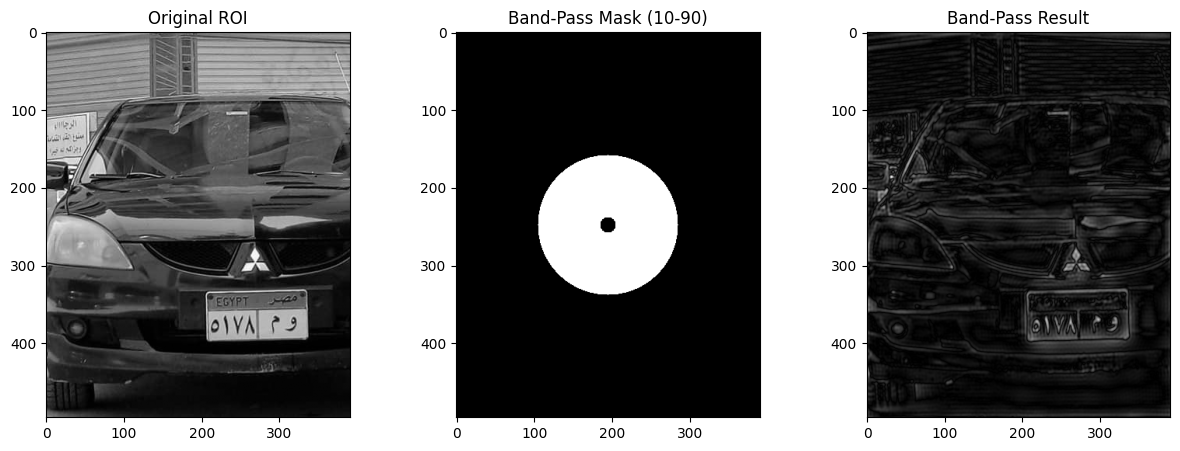

In [59]:
# Part 13: Frequency Domain — Ideal Band-Pass Filtering
import numpy as np

def ideal_bandpass_filter(image, d_low, d_high):
    # 1. Fourier Transform
    dft = np.fft.fft2(image)
    dft_shifted = np.fft.fftshift(dft)
    
    # 2. Create Distance Matrix
    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2
    x, y = np.ogrid[:rows, :cols]
    dist_matrix = np.sqrt((x - crow)**2 + (y - ccol)**2)
    
    # 3. Create Band-Pass Mask
    # Mask is 1 where distance is between d_low and d_high, else 0
    mask = np.logical_and(dist_matrix >= d_low, dist_matrix <= d_high)
    
    # 4. Apply Mask and Inverse Fourier Transform
    filtered_dft = dft_shifted * mask
    f_ishift = np.fft.ifftshift(filtered_dft)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)
    
    return img_back, mask

# Parameters (Try adjusting these to see the effect on the plate)
D_LOW = 10
D_HIGH = 90

bandpass_img, bp_mask = ideal_bandpass_filter(plate_roi, D_LOW, D_HIGH)

# Visualization
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(plate_roi, cmap='gray'); plt.title('Original ROI')
plt.subplot(1, 3, 2); plt.imshow(bp_mask, cmap='gray'); plt.title(f'Band-Pass Mask ({D_LOW}-{D_HIGH})')
plt.subplot(1, 3, 3); plt.imshow(bandpass_img, cmap='gray'); plt.title('Band-Pass Result')
plt.show()


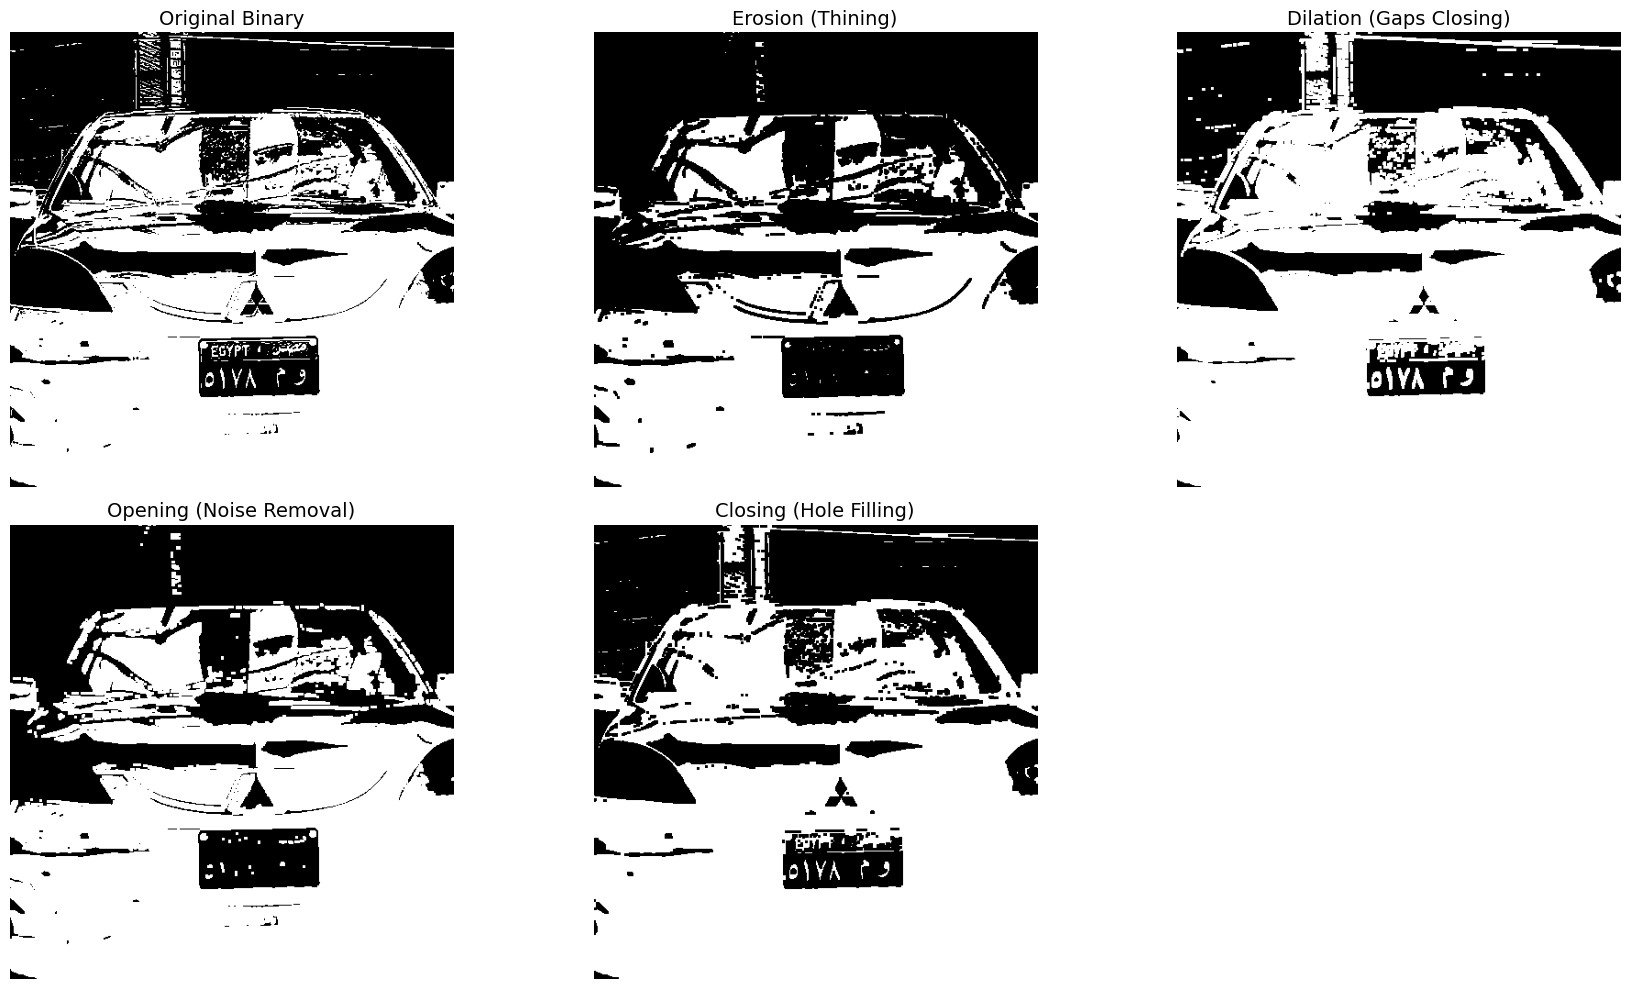

In [62]:
# Part 14: Morphological Operations Lab — Cleaning the Plate
import cv2

# 1. First, we get a binary version of the plate (Thresholding)
# We use the cropped plate_roi we selected earlier
gray_plate = cv2.cvtColor(plate_roi, cv2.COLOR_BGR2GRAY) if len(plate_roi.shape) == 3 else plate_roi
_, binary_plate = cv2.threshold(gray_plate, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 2. Define a Kernel (The tool that defines the operation size)
kernel = np.ones((3,3), np.uint8)

# 3. Apply Operations
erosion = cv2.erode(binary_plate, kernel, iterations=1)     # Thins the letters
dilation = cv2.dilate(binary_plate, kernel, iterations=1)   # Thickens the letters
opening = cv2.morphologyEx(binary_plate, cv2.MORPH_OPEN, kernel)   # Removes noise (dots)
closing = cv2.morphologyEx(binary_plate, cv2.MORPH_CLOSE, kernel) # Fills holes

# Visualization
plt.figure(figsize=(18, 10))

titles = ['Original Binary', 'Erosion (Thining)', 'Dilation (Gaps Closing)', 
          'Opening (Noise Removal)', 'Closing (Hole Filling)']
images = [binary_plate, erosion, dilation, opening, closing]

for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [48]:
# Part 15: Automated Batch Processing for the entire Dataset
import os
import glob

def batch_process_dataset(input_folder, output_folder):
    # 1. Create output directory if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    # 2. Get all image paths
    image_paths = glob.glob(os.path.join(input_folder, "*.jpg")) # Adjust extension if needed (.png)
    print(f"Found {len(image_paths)} images. Starting processing...")

    for i, img_path in enumerate(image_paths):
        # Load image
        img = cv2.imread(img_path)
        if img is None: continue
        
        # --- APPLY OUR BEST PREPROCESSING RECIPE ---
        # Example: Grayscale -> CLAHE (Adaptive Hist Eq) -> Denoising
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(gray)
        final = cv2.medianBlur(enhanced, 3)
        # --------------------------------------------

        # Save the result
        filename = os.path.basename(img_path)
        cv2.imwrite(os.path.join(output_folder, filename), final)
        
        # Progress bar (Optional)
        if (i+1) % 100 == 0:
            print(f"Processed {i+1}/{len(image_paths)} images...")

    print(f"Success! All processed images are saved in: {output_folder}")

# --- RUN THE BATCH PROCESSOR ---
# Note: This might take a minute for 2000 images
OUTPUT_PATH = r"C:\Users\moman\Desktop\Egyptian License Plates\Output_Processed"
batch_process_dataset(DATASET_PATH, OUTPUT_PATH) # Uncomment this line to run it


Found 2085 images. Starting processing...
Processed 100/2085 images...
Processed 200/2085 images...
Processed 300/2085 images...
Processed 400/2085 images...
Processed 500/2085 images...
Processed 600/2085 images...
Processed 700/2085 images...
Processed 800/2085 images...
Processed 900/2085 images...
Processed 1000/2085 images...
Processed 1100/2085 images...
Processed 1200/2085 images...
Processed 1300/2085 images...
Processed 1400/2085 images...
Processed 1500/2085 images...
Processed 1600/2085 images...
Processed 1700/2085 images...
Processed 1800/2085 images...
Processed 1900/2085 images...
Processed 2000/2085 images...
Success! All processed images are saved in: C:\Users\moman\Desktop\Egyptian License Plates\Output_Processed
